In [1]:
import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk"
os.environ["PYSPARK_PYTHON"] = "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/home/varunadhityagb/localProjects/BigData-Intrusion/.venv/bin/python3"

In [2]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import create_map, lit
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from itertools import chain
 
HDFS_BASE  = "hdfs://lattitude7420:9000/ids2018"
TRAIN_PATH = f"{HDFS_BASE}/train"
TEST_PATH  = f"{HDFS_BASE}/test"
MODEL_OUT  = f"{HDFS_BASE}/models/multiclass_weighted_smote"

In [3]:
spark = SparkSession.builder \
    .appName("IDS2018-Weighted-v2") \
    .master("spark://lattitude7420:7077") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.cores", "2") \
    .config("spark.memory.fraction", "0.6") \
    .config("spark.memory.storageFraction", "0.3") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)
print("UI:", spark.sparkContext.uiWebUrl)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/22 19:04:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.8
UI: http://lattitude7420:4040


In [4]:
train = spark.read.parquet(TRAIN_PATH)
test  = spark.read.parquet(TEST_PATH)
train.cache()
test.cache()
print(f"Train: {train.count():,} | Test: {test.count():,}")

26/05/22 19:04:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 6:===============================================>          (9 + 2) / 11]

Train: 7,229,310 | Test: 1,806,815


In [5]:
eng_cols = ["log_flow_duration", "pkt_ratio", "byte_ratio", "hour_of_day", "day_of_week"]
exclude  = ["Label", "binary_label", "attack_type", "Flow Byts/s", "Flow Pkts/s"]
 
final_features = [c for c in train.columns if c not in exclude] + eng_cols
seen = set()
final_features = [c for c in final_features if not (c in seen or seen.add(c))]
print(f"Features: {len(final_features)}")  # expect 81

Features: 81


In [6]:
wa_df = train.filter(F.col("attack_type") == "WebAttack").toPandas()
print(f"WebAttack rows: {len(wa_df)}")  # expect 749

[Stage 10:======================================>                  (8 + 4) / 12]

WebAttack rows: 749


In [7]:
SMOTE_TARGET = 5000  # synthetic WebAttack target; tune up if F1 still low
 
# Need 2 classes for SMOTE — use small Benign sample as reference, discard after
benign_sample = train.filter(F.col("attack_type") == "Benign").limit(1000).toPandas()
 
combined = pd.concat([wa_df, benign_sample], ignore_index=True)
 
X = combined[final_features].values.astype(np.float32)
y = (combined["attack_type"] == "WebAttack").astype(int).values  # 1=WebAttack 0=Benign
 
k = min(5, len(wa_df) - 1)  # k_neighbors must be < minority class size
sm = SMOTE(sampling_strategy={1: SMOTE_TARGET}, k_neighbors=k, random_state=42)
X_res, y_res = sm.fit_resample(X, y)
 
# SMOTE appends synthetic rows after original rows
n_original   = len(combined)
X_synthetic  = X_res[n_original:]
y_synthetic  = y_res[n_original:]
 
assert all(y_synthetic == 1), f"Expected all synthetic rows = WebAttack, got: {set(y_synthetic)}"
print(f"Synthetic WebAttack rows: {len(X_synthetic)}")

Synthetic WebAttack rows: 4251


In [8]:
synthetic_pd = pd.DataFrame(X_synthetic, columns=final_features)
synthetic_pd["attack_type"]  = "WebAttack"
synthetic_pd["binary_label"] = 1.0
# Label col — keep consistent with train schema
synthetic_pd["Label"] = "WebAttack"
 
# Cast floats to match train parquet schema
for c in final_features:
    synthetic_pd[c] = synthetic_pd[c].astype(np.float32)
 
# Create Spark df — allow train to have extra cols not in synthetic
synthetic_spark = spark.createDataFrame(synthetic_pd)
 
# unionByName needs matching schemas — add missing cols as null
train_cols  = set(train.columns)
synth_cols  = set(synthetic_spark.columns)
for missing in train_cols - synth_cols:
    dtype = dict(train.dtypes)[missing]
    synthetic_spark = synthetic_spark.withColumn(missing, F.lit(None).cast(dtype))
 
train_augmented = train.unionByName(synthetic_spark)
train_augmented.cache()
 
print("Augmented class distribution:")
train_augmented.groupBy("attack_type").count().orderBy("count", ascending=False).show()

Augmented class distribution:


+--------------+-------+
|   attack_type|  count|
+--------------+-------+
|        Benign|5446577|
|          DDoS| 596091|
|           DoS| 523538|
|           Bot| 228915|
|FTP-BruteForce| 154880|
|SSH-Bruteforce| 150013|
| Infilteration| 128547|
|     WebAttack|   5000|
+--------------+-------+



In [9]:
label_counts = train_augmented.groupBy("attack_type").count().toPandas()
total     = label_counts["count"].sum()
n_classes = len(label_counts)
MAX_WEIGHT = 50.0
 
weight_map = {}
for _, row in label_counts.iterrows():
    raw = total / (n_classes * row["count"])
    weight_map[row["attack_type"]] = min(raw, MAX_WEIGHT)
 
print("Capped weights:")
for k_, v in sorted(weight_map.items(), key=lambda x: -x[1]):
    print(f"  {k_:<22} {v:.4f}")
 
mapping_expr   = create_map([lit(x) for x in chain(*weight_map.items())])
train_weighted = train_augmented.withColumn("class_weight", mapping_expr[F.col("attack_type")])

[Stage 16:=====================================================>  (21 + 1) / 22]

Capped weights:
  WebAttack              50.0000
  Infilteration          7.0340
  SSH-Bruteforce         6.0274
  FTP-BruteForce         5.8380
  Bot                    3.9499
  DoS                    1.7271
  DDoS                   1.5169
  Benign                 0.1660


In [10]:
assembler = VectorAssembler(
    inputCols=final_features,
    outputCol="raw_features",
    handleInvalid="skip"
)
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features"
)
indexer = StringIndexer(
    inputCol="attack_type",
    outputCol="mc_label",
    handleInvalid="keep"
)
rf = RandomForestClassifier(
    labelCol="mc_label",
    featuresCol="features",
    weightCol="class_weight",
    numTrees=20,
    maxDepth=8,
    maxBins=32,
    subsamplingRate=0.8,
    seed=42
)
 
pipeline = Pipeline(stages=[assembler, scaler, indexer, rf])
 
print("Training SMOTE model...")
model_smote = pipeline.fit(train_weighted)
print("Done.")

Training SMOTE model...


26/05/22 19:16:41 WARN DAGScheduler: Broadcasting large task binary with size 1208.7 KiB
                                                                                

Done.


In [11]:
model_smote.write().overwrite().save(MODEL_OUT)
print(f"\nModel saved → {MODEL_OUT}")

[Stage 59:==================================>                      (6 + 4) / 10]


Model saved → hdfs://lattitude7420:9000/ids2018/models/multiclass_weighted_smote


In [12]:
test_weighted = test.withColumn("class_weight", mapping_expr[F.col("attack_type")])
preds = model_smote.transform(test_weighted)
preds.cache()
 
mc_f1   = MulticlassClassificationEvaluator(labelCol="mc_label", metricName="f1").evaluate(preds)
mc_acc  = MulticlassClassificationEvaluator(labelCol="mc_label", metricName="accuracy").evaluate(preds)
mc_prec = MulticlassClassificationEvaluator(labelCol="mc_label", metricName="weightedPrecision").evaluate(preds)
mc_rec  = MulticlassClassificationEvaluator(labelCol="mc_label", metricName="weightedRecall").evaluate(preds)
 
print("="*42)
print("   WEIGHTED + SMOTE MULTICLASS RESULTS")
print("="*42)
print(f"  F1        : {mc_f1:.4f}")
print(f"  Accuracy  : {mc_acc:.4f}")
print(f"  Precision : {mc_prec:.4f}")
print(f"  Recall    : {mc_rec:.4f}")
print("="*42)
 

26/05/22 19:17:15 WARN DAGScheduler: Broadcasting large task binary with size 1011.7 KiB
26/05/22 19:18:25 WARN DAGScheduler: Broadcasting large task binary with size 1025.8 KiB
26/05/22 19:18:29 WARN DAGScheduler: Broadcasting large task binary with size 1025.8 KiB
26/05/22 19:18:32 WARN DAGScheduler: Broadcasting large task binary with size 1025.8 KiB
26/05/22 19:18:33 WARN DAGScheduler: Broadcasting large task binary with size 1025.8 KiB
[Stage 69:==================================================>     (10 + 1) / 11]

   WEIGHTED + SMOTE MULTICLASS RESULTS
  F1        : 0.8378
  Accuracy  : 0.7563
  Precision : 0.9783
  Recall    : 0.7563


In [13]:
labels = model_smote.stages[2].labels  # stage 2 = indexer
n      = len(labels)
 
cm_raw    = preds.groupBy("mc_label", "prediction").count().toPandas()
cm_matrix = np.zeros((n, n))
for _, row in cm_raw.iterrows():
    i, j = int(row["mc_label"]), int(row["prediction"])
    if i < n and j < n:
        cm_matrix[i][j] = row["count"]
 
rows = []
for i, name in enumerate(labels):
    tp   = cm_matrix[i][i]
    fp   = cm_matrix[:, i].sum() - tp
    fn   = cm_matrix[i, :].sum() - tp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    rows.append({"Class": name, "Precision": round(prec, 4),
                 "Recall": round(rec, 4), "F1": round(f1, 4)})
 
per_class_df = pd.DataFrame(rows)
print(per_class_df.to_string(index=False))

26/05/22 19:18:36 WARN DAGScheduler: Broadcasting large task binary with size 1031.1 KiB
[Stage 71:==================================================>     (10 + 1) / 11]

         Class  Precision  Recall     F1
        Benign     0.9972  0.6787 0.8076
          DDoS     0.9835  0.9996 0.9915
           DoS     0.9938  0.9980 0.9959
           Bot     0.9701  0.9989 0.9843
FTP-BruteForce     0.9941  1.0000 0.9970
SSH-Bruteforce     0.9995  0.9998 0.9997
 Infilteration     0.0646  0.9193 0.1207
     WebAttack     0.0304  0.9162 0.0589


26/05/22 19:18:40 WARN DAGScheduler: Broadcasting large task binary with size 1032.0 KiB
                                                                                

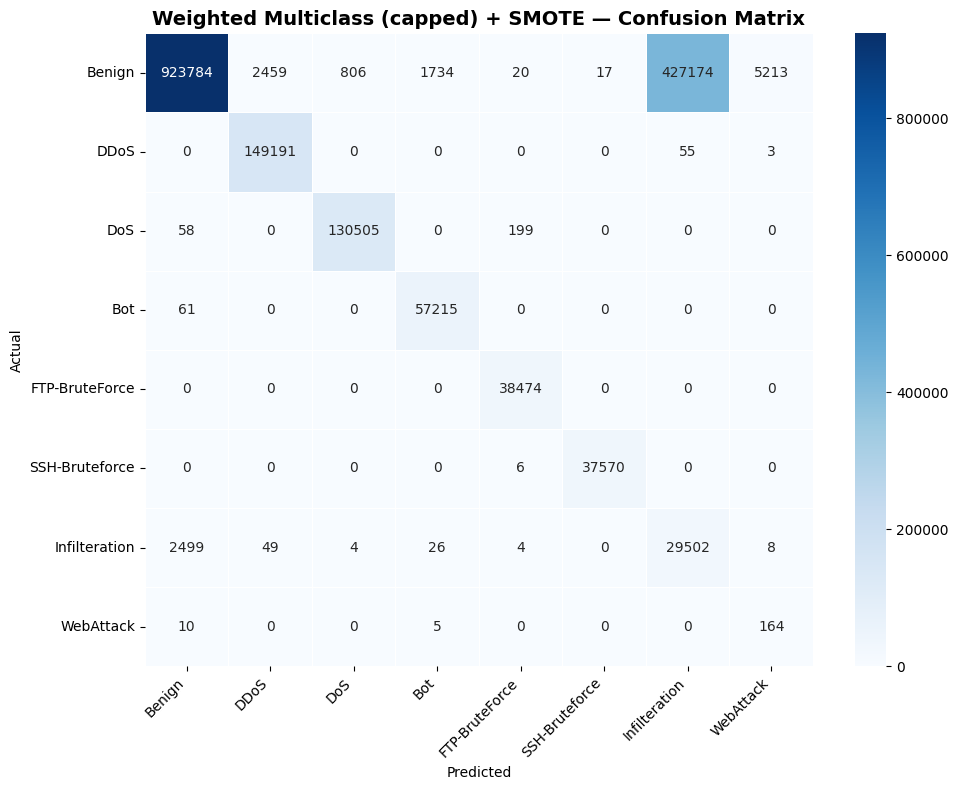

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm_matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
plt.title('Weighted Multiclass (capped) + SMOTE — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_weighted_capped_smote.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
old = {
    "Benign":         {"Recall": 0.6753, "F1": 0.8055},
    "DDoS":           {"Recall": 0.9993, "F1": 0.9906},
    "DoS":            {"Recall": 0.9983, "F1": 0.9988},
    "Bot":            {"Recall": 0.9991, "F1": 0.9887},
    "FTP-BruteForce": {"Recall": 1.0000, "F1": 0.9971},
    "SSH-Bruteforce": {"Recall": 0.9998, "F1": 0.9999},
    "Infilteration":  {"Recall": 0.9459, "F1": 0.1214},
    "WebAttack":      {"Recall": 0.4134, "F1": 0.3109},
}
 
print(f"\n{'Class':<20} {'Old Recall':>12} {'New Recall':>12} {'Old F1':>10} {'New F1':>10}")
print("-" * 68)
for row in per_class_df.itertuples():
    o = old.get(row.Class, {"Recall": 0, "F1": 0})
    delta_r = row.Recall - o["Recall"]
    arrow = "▲" if delta_r > 0.01 else "▼" if delta_r < -0.01 else "─"
    print(f"{row.Class:<20} {o['Recall']:>12.4f} {row.Recall:>12.4f} "
          f"{o['F1']:>10.4f} {row.F1:>10.4f}   {arrow}")


Class                  Old Recall   New Recall     Old F1     New F1
--------------------------------------------------------------------
Benign                     0.6753       0.6787     0.8055     0.8076   ─
DDoS                       0.9993       0.9996     0.9906     0.9915   ─
DoS                        0.9983       0.9980     0.9988     0.9959   ─
Bot                        0.9991       0.9989     0.9887     0.9843   ─
FTP-BruteForce             1.0000       1.0000     0.9971     0.9970   ─
SSH-Bruteforce             0.9998       0.9998     0.9999     0.9997   ─
Infilteration              0.9459       0.9193     0.1214     0.1207   ▼
WebAttack                  0.4134       0.9162     0.3109     0.0589   ▲


In [ ]:
spark.stop()